# Project Description
We are trying to build a machine learning model that predicts which awards, if any, an NBA player is expected to get based on their performance data. These awards include categories such as Most Valuable Player, All Star, or no award. We aim to answer: can player performance metrics be used to accurately predict which awards an NBA player will recieve?

Our model will be a multi-output classification model using a Random Forest Classifier, where a player can be predicted to get multiple awards. Our data set contains observations of player metrics for a given year, from 2021 to 2025.

We use a Classifier Chain on the model since players who receive certain awards such as an MVP vote, are more likely to make an all NBA team. This will allow the model to learn from the other classifications.

We will clean the data by handling missing values, standardizing player stats, and restructuring the awards column into multiple binary classes. We will remove/ignore less relevant features for model simplicity.

We expect to be able to predict most awards relatively precisely, but we don't expect to predict defensive awards nearly as well. This is due to the fact that defensive metrics are just harder to objectively measure. 

We test our validation data with many threshold values in order to maximize F1 score. We then evaluate our model's precision, recall, and F1 scores on our testing data with the selected threshold value. We expect the model to predict awards conservatively, missing some true award winners as a tradeoff.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import ClassifierChain
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import BaggingClassifier

## Data Cleaning

In [2]:
# Load in datasets

# Simple Metrics
nba_2021 = pd.read_csv('NBA_2021.csv')
nba_2022 = pd.read_csv('NBA_2022.csv')
nba_2023 = pd.read_csv('NBA_2023.csv')
nba_2024 = pd.read_csv('NBA_2024.csv')
nba_2025 = pd.read_csv('NBA_2025.csv')

# Advanced Metrics
nba_2021_advanced = pd.read_csv('NBA_2021_Advanced.csv')
nba_2022_advanced = pd.read_csv('NBA_2022_Advanced.csv')
nba_2023_advanced = pd.read_csv('NBA_2023_Advanced.csv')
nba_2024_advanced = pd.read_csv('NBA_2024_Advanced.csv')
nba_2025_advanced = pd.read_csv('NBA_2025_Advanced.csv')

In [3]:
# Add a year identification column

nba_2021['Year'] = '2021'
nba_2022['Year'] = '2022'
nba_2023['Year'] = '2023'
nba_2024['Year'] = '2024'
nba_2025['Year'] = '2025'

nba_2021_advanced['Year'] = '2021'
nba_2022_advanced['Year'] = '2022'
nba_2023_advanced['Year'] = '2023'
nba_2024_advanced['Year'] = '2024'
nba_2025_advanced['Year'] = '2025'

In [4]:
# Rename VORP in 2025 to match other years
nba_2025_advanced.rename(columns={nba_2025_advanced.columns[nba_2025_advanced.columns.str.contains('VORP')][0]: 'VORP'}, inplace=True)

In [5]:
# Concatinate and merge datasets
nba_count = pd.concat([nba_2021, nba_2022, nba_2023, nba_2024, nba_2025], axis = 0)
nba_advanced = pd.concat([nba_2021_advanced, nba_2022_advanced, nba_2023_advanced,
                          nba_2024_advanced, nba_2025_advanced], axis = 0) 

nba_advanced = nba_advanced.drop(columns = ['Rk', 'Age', 'Team', 'Pos', 'G', 'GS',
                                            'MP', 'Player-additional', 'Awards']) # Drop duplicate columnss
nba = nba_count.merge(nba_advanced, on = ['Player', 'Year'])

In [6]:
# Filter players who dont play often
nba = nba[nba['G'] >= 40]
nba = nba[nba['MP'] >= 10]

In [7]:
# Parse Awards from Awards column and assign True and False
nba['Awards'] = nba['Awards'].fillna('None')
nba['MVP_Vote'] = nba['Awards'].str.contains('MVP', na = False)
nba['AS'] = nba['Awards'].str.contains('AS', na = False)
nba['All_NBA'] = nba['Awards'].str.contains('NBA', na = False)
nba['DPOY_Vote'] = nba['Awards'].str.contains('DPOY', na = False)
nba['All_DEF'] = nba['Awards'].str.contains('DEF', na = False)

In [8]:
# Change True and False to 1 and 0
nba[['MVP_Vote', 'AS', 'All_NBA', 'DPOY_Vote', 'All_DEF']] = nba[['MVP_Vote', 'AS', 'All_NBA', 'DPOY_Vote', 'All_DEF']].astype(int)
nba

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,WS/48,OBPM,DBPM,BPM,VORP,MVP_Vote,AS,All_NBA,DPOY_Vote,All_DEF
0,1,Stephen Curry,32,GSW,PG,63,63,34.2,10.4,21.7,...,0.201,8.3,0.4,8.7,5.8,1,1,1,0,0
1,2,Bradley Beal,27,WAS,SG,60,60,35.8,11.2,23.0,...,0.132,4.8,-1.4,3.4,2.9,0,1,1,0,0
2,3,Damian Lillard,30,POR,PG,67,67,35.8,9.0,19.9,...,0.209,7.5,-1.3,6.3,5.0,1,1,1,0,0
3,4,Joel Embiid,26,PHI,C,51,51,31.1,9.0,17.6,...,0.266,6.3,1.2,7.5,3.8,1,1,1,1,1
4,5,Giannis Antetokounmpo,26,MIL,PF,61,61,33.0,10.3,18.0,...,0.244,6.2,2.8,9.0,5.6,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2721,466,Gary Harris,30,ORL,SG,48,3,14.8,1.1,2.8,...,0.067,-3.9,1.2,-2.7,-0.1,0,0,0,0,0
2740,485,Dillon Jones,23,OKC,SF,54,3,10.2,0.9,2.5,...,0.067,-4.3,0.3,-4.0,-0.3,0,0,0,0,0
2744,489,John Konchar,28,MEM,SG,46,4,12.1,0.9,2.0,...,0.131,-0.7,2.3,1.7,0.5,0,0,0,0,0
2757,502,Dwight Powell,33,DAL,C,55,3,10.0,0.8,1.1,...,0.147,-1.5,1.5,0.0,0.3,0,0,0,0,0


In [9]:
# Replaces NULLs in Percentage columns with zeros
nba.fillna(0, inplace = True)
nba

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,WS/48,OBPM,DBPM,BPM,VORP,MVP_Vote,AS,All_NBA,DPOY_Vote,All_DEF
0,1,Stephen Curry,32,GSW,PG,63,63,34.2,10.4,21.7,...,0.201,8.3,0.4,8.7,5.8,1,1,1,0,0
1,2,Bradley Beal,27,WAS,SG,60,60,35.8,11.2,23.0,...,0.132,4.8,-1.4,3.4,2.9,0,1,1,0,0
2,3,Damian Lillard,30,POR,PG,67,67,35.8,9.0,19.9,...,0.209,7.5,-1.3,6.3,5.0,1,1,1,0,0
3,4,Joel Embiid,26,PHI,C,51,51,31.1,9.0,17.6,...,0.266,6.3,1.2,7.5,3.8,1,1,1,1,1
4,5,Giannis Antetokounmpo,26,MIL,PF,61,61,33.0,10.3,18.0,...,0.244,6.2,2.8,9.0,5.6,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2721,466,Gary Harris,30,ORL,SG,48,3,14.8,1.1,2.8,...,0.067,-3.9,1.2,-2.7,-0.1,0,0,0,0,0
2740,485,Dillon Jones,23,OKC,SF,54,3,10.2,0.9,2.5,...,0.067,-4.3,0.3,-4.0,-0.3,0,0,0,0,0
2744,489,John Konchar,28,MEM,SG,46,4,12.1,0.9,2.0,...,0.131,-0.7,2.3,1.7,0.5,0,0,0,0,0
2757,502,Dwight Powell,33,DAL,C,55,3,10.0,0.8,1.1,...,0.147,-1.5,1.5,0.0,0.3,0,0,0,0,0


## Initial model fitting with every variable

In [10]:
# Assigning variables
X = nba[['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', 
         '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 
         'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PER',
         'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%',
         'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP']] # Input Features

y = nba[['MVP_Vote', 'AS', 'All_NBA', 'DPOY_Vote', 'All_DEF']] # Output Features

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=22) # split data to train and test
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=22) # split train to train and validation

In [11]:
# Scaling inputs
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [12]:
# Fitting model
base_rf = RandomForestClassifier(n_estimators=100, random_state=22, class_weight={0: 1, 1: 25}) # Initialize random forest
chain = ClassifierChain(base_rf, order='random', random_state=22) # Initialize classifier chain
chain.fit(X_train, y_train)

,estimator estimator: estimatorThe base estimator from which the classifier chain is built.,RandomForestC...ndom_state=22)
,"order order: array-like of shape (n_outputs,) or 'random', default=NoneIf `None`, the order will be determined by the order of columns inthe label matrix Y.:: order = [0, 1, 2, ..., Y.shape[1] - 1]The order of the chain can be explicitly set by providing a list ofintegers. For example, for a chain of length 5.:: order = [1, 3, 2, 4, 0]means that the first model in the chain will make predictions forcolumn 1 in the Y matrix, the second model will make predictionsfor column 3, etc.If order is `random` a random ordering will be used.",'random'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines whether to use cross validated predictions or truelabels for the results of previous estimators in the chain.Possible inputs for cv are:- None, to use true labels when fitting,- integer, to specify the number of folds in a (Stratified)KFold,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.",None
,"chain_method chain_method: {'predict', 'predict_proba', 'predict_log_proba', 'decision_function'} or list of such str's, default='predict'Prediction method to be used by estimators in the chain forthe 'prediction' features of previous estimators in the chain.- if `str`, name of the method;- if a list of `str`, provides the method names in order of preference. The method used corresponds to the first method in the list that is implemented by `base_estimator`... versionadded:: 1.5",'predict'
,"random_state random_state: int, RandomState instance or None, optional (default=None)If ``order='random'``, determines random number generation for thechain order.In addition, it controls the random seed given at each `base_estimator`at each chaining iteration. Thus, it is only used when `base_estimator`exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",22
,"verbose verbose: bool, default=FalseIf True, chain progress is output as each model is completed... versionadded:: 1.2",False
,"base_estimator base_estimator: estimator, default=""deprecated""Use `estimator` instead... deprecated:: 1.7 `base_estimator` is deprecated and will be removed in 1.9. Use `estimator` instead.",'deprecated'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [13]:
print(chain.order_)
print(y.columns)

[1 2 3 0 4]
Index(['MVP_Vote', 'AS', 'All_NBA', 'DPOY_Vote', 'All_DEF'], dtype='object')


In [14]:
# Evaluating best threshold
y_probs = chain.predict_proba(X_val)
for i in [0.15, 0.20, 0.25, 0.30, .5]:
    y_pred = (y_probs >= i).astype(int)
    report = classification_report(y_val, y_pred, zero_division=0, output_dict=True)
    print(f"Threshold of {i} = Macro F1: {report['macro avg']['f1-score']:.4f}")

Threshold of 0.15 = Macro F1: 0.5139
Threshold of 0.2 = Macro F1: 0.4934
Threshold of 0.25 = Macro F1: 0.4695
Threshold of 0.3 = Macro F1: 0.4559
Threshold of 0.5 = Macro F1: 0.3989


In [15]:
# Testing the model with chosen threshold
y_probs = chain.predict_proba(X_test)
threshold = 0.15 # Predict award above 20% chance
y_pred = (y_probs >= threshold).astype(int)

target_names = ['MVP_Vote', 'AS', 'All_NBA', 'DPOY_Vote', 'All_DEF']
print(classification_report(y_test, y_pred, target_names = target_names, zero_division=0))

              precision    recall  f1-score   support

    MVP_Vote       0.53      0.80      0.64        10
          AS       0.67      0.83      0.74        24
     All_NBA       0.67      0.80      0.73        15
   DPOY_Vote       0.40      0.73      0.52        11
     All_DEF       0.00      0.00      0.00        11

   micro avg       0.57      0.68      0.62        71
   macro avg       0.45      0.63      0.52        71
weighted avg       0.50      0.68      0.57        71
 samples avg       0.07      0.06      0.06        71



## Feature Selection

   features  importance
5       FGA    0.070201
45     VORP    0.054991
35     BLK%    0.051638
42     OBPM    0.047747
25      PTS    0.046672
4        FG    0.043692
22      BLK    0.041037
11      2PA    0.037778
33     AST%    0.033007
20      AST    0.032078
3        MP    0.030286
37     USG%    0.027069
1         G    0.026605
40       WS    0.025993
9       3P%    0.024763
44      BPM    0.024595
8       3PA    0.022839
28     3PAr    0.022515
29      FTr    0.022294
15      FTA    0.021122
7        3P    0.019088
43     DBPM    0.018954
27      TS%    0.017614
24       PF    0.016049
38      OWS    0.015916
6       FG%    0.015823
17      ORB    0.015577
19      TRB    0.013133
26      PER    0.011954
0       Age    0.011953
32     TRB%    0.011330
30     ORB%    0.011115
41    WS/48    0.010741
2        GS    0.010738
10       2P    0.010529
34     STL%    0.010213
31     DRB%    0.010173
36     TOV%    0.009966
14       FT    0.009776
16      FT%    0.009175
23      TOV    0

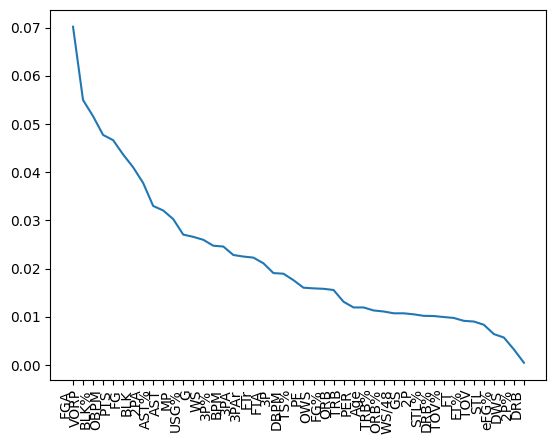

In [16]:
base_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=22)
base_rf.fit(X_train, y_train)
feature_df = pd.DataFrame({
    "features" : X.columns,
    "importance" : base_rf.feature_importances_})
feature_df = feature_df.sort_values('importance', ascending = False)
print(feature_df)

plt.plot(feature_df['features'], feature_df['importance'])
plt.xticks(rotation=90, ha='right')
plt.show()

## Updated Model

In [17]:
# Assigning variables
X = nba[['Age', 'G', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', 
         '3P%', '2PA', 'FTA', 'FT%', 'ORB', 
         'TRB', 'AST', 'BLK', 'PF', 'PTS', 'PER',
         'TS%', '3PAr', 'FTr', 'AST%', 'BLK%',
         'USG%', 'OWS', 'WS', 'OBPM', 'DBPM', 'BPM', 'VORP']] # Input Features

y = nba[['MVP_Vote', 'AS', 'All_NBA', 'DPOY_Vote', 'All_DEF']] # Output Features

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=22) # split data to train and test
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=22) # split train to train and validation

In [18]:
# Scaling inputs
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [19]:
# Fitting model
base_rf = RandomForestClassifier(n_estimators=100, random_state=22, class_weight={0: 1, 1: 25}) # Initialize random forest
chain = ClassifierChain(base_rf, order=[1, 4, 2, 3, 0], random_state=22) # Initialize classifier chain
chain.fit(X_train, y_train)

,estimator estimator: estimatorThe base estimator from which the classifier chain is built.,RandomForestC...ndom_state=22)
,"order order: array-like of shape (n_outputs,) or 'random', default=NoneIf `None`, the order will be determined by the order of columns inthe label matrix Y.:: order = [0, 1, 2, ..., Y.shape[1] - 1]The order of the chain can be explicitly set by providing a list ofintegers. For example, for a chain of length 5.:: order = [1, 3, 2, 4, 0]means that the first model in the chain will make predictions forcolumn 1 in the Y matrix, the second model will make predictionsfor column 3, etc.If order is `random` a random ordering will be used.","[1, 4, ...]"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines whether to use cross validated predictions or truelabels for the results of previous estimators in the chain.Possible inputs for cv are:- None, to use true labels when fitting,- integer, to specify the number of folds in a (Stratified)KFold,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.",None
,"chain_method chain_method: {'predict', 'predict_proba', 'predict_log_proba', 'decision_function'} or list of such str's, default='predict'Prediction method to be used by estimators in the chain forthe 'prediction' features of previous estimators in the chain.- if `str`, name of the method;- if a list of `str`, provides the method names in order of preference. The method used corresponds to the first method in the list that is implemented by `base_estimator`... versionadded:: 1.5",'predict'
,"random_state random_state: int, RandomState instance or None, optional (default=None)If ``order='random'``, determines random number generation for thechain order.In addition, it controls the random seed given at each `base_estimator`at each chaining iteration. Thus, it is only used when `base_estimator`exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",22
,"verbose verbose: bool, default=FalseIf True, chain progress is output as each model is completed... versionadded:: 1.2",False
,"base_estimator base_estimator: estimator, default=""deprecated""Use `estimator` instead... deprecated:: 1.7 `base_estimator` is deprecated and will be removed in 1.9. Use `estimator` instead.",'deprecated'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [20]:
# Evaluating best threshold
y_probs = chain.predict_proba(X_val)
for i in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_probs >= i).astype(int)
    report = classification_report(y_val, y_pred, zero_division=0, output_dict=True)
    print(f"Threshold of {i} = Micro F1: {report['micro avg']['f1-score']:.4f}")

Threshold of 0.1 = Micro F1: 0.5876
Threshold of 0.2 = Micro F1: 0.6289
Threshold of 0.3 = Micro F1: 0.6069
Threshold of 0.4 = Micro F1: 0.6087
Threshold of 0.5 = Micro F1: 0.6190


In [21]:
# Testing the model with chosen threshold
y_probs = chain.predict_proba(X_test)
threshold = 0.2 # Predict award above 20% chance
y_pred = (y_probs >= threshold).astype(int)

target_names = ['MVP_Vote', 'AS', 'All_NBA', 'DPOY_Vote', 'All_DEF']
print(classification_report(y_test, y_pred, target_names = target_names, zero_division=0))

              precision    recall  f1-score   support

    MVP_Vote       0.62      0.80      0.70        10
          AS       0.75      0.88      0.81        24
     All_NBA       0.71      0.80      0.75        15
   DPOY_Vote       0.50      0.36      0.42        11
     All_DEF       0.44      0.64      0.52        11

   micro avg       0.63      0.73      0.68        71
   macro avg       0.60      0.70      0.64        71
weighted avg       0.63      0.73      0.68        71
 samples avg       0.07      0.07      0.07        71



## Predictions

In [22]:
# Make award predicitons.
def make_prediction(player_metrics):
    player_scaled = scaler.transform(player_metrics)

    player_probs = chain.predict_proba(player_scaled)

    pred_bool = player_probs >= 0.2
    awards = []
    award_names = ['MVP Vote', 'All-Star', 'All-NBA Team', 'Defensive Player of the Year Vote', 'All-Defensive Team']
    for i in range(len(award_names)):
        if pred_bool[0][i]:
            awards.append(award_names[i])
    if len(awards) > 0:
        print("Predicted awards:")
        for i in awards:
            print(i)
    else:
        print("Predicted awards:")
        print("None")

In [23]:
# Test player
warnings.simplefilter('ignore')
hypothetical_player = nba[(nba['Player'] == 'Stephen Curry') & (nba['Year'] == '2023')][X.columns.to_list()]
make_prediction(hypothetical_player)

Predicted awards:
MVP Vote
All-Star
All-NBA Team


In [24]:
nba[(nba['Player'] == 'Stephen Curry') & (nba['Year'] == '2023')]['Awards']

1151    MVP-9CPOY-9ASNBA2
Name: Awards, dtype: object

In [25]:
warnings.simplefilter('ignore')
hypothetical_player = nba[(nba['Player'] == 'Victor Wembanyama') & (nba['Year'] == '2025')][X.columns.to_list()]
make_prediction(hypothetical_player)

Predicted awards:
All-Star


In [26]:
nba[(nba['Player'] == 'Victor Wembanyama') & (nba['Year'] == '2025')]['Awards']

2276    AS
Name: Awards, dtype: object

### References
https://scikit-learn.org/stable/auto_examples/multioutput/plot_classifier_chain_yeast.html  
https://scikit-learn.org/stable/modules/generated/sklearn.multioutput.ClassifierChain.html  
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html  